In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ── Carga tu dataframe (ajusta la ruta) ──────────────────────────────────────
df = pd.read_csv('heart_2022_with_nans.csv')

# ── 1. Forma general ─────────────────────────────────────────────────────────
print("=" * 60)
print(f"SHAPE: {df.shape}")

# ── 2. Variable objetivo ─────────────────────────────────────────────────────
target_col = "HadHeartAttack"  # <-- cambia esto
print("\n--- TARGET ---")
print(df[target_col].value_counts())

# Convert 'No' to 0 and 'Yes' to 1 for numerical calculation
df_target_numeric = df[target_col].map({'No': 0, 'Yes': 1})
print(f"% positivos: {df_target_numeric.mean()*100:.2f}%")

# ── 3. Tipos de datos ────────────────────────────────────────────────────────
print("\n--- TIPOS DE DATOS ---")
print(df.dtypes.value_counts())

# ── 4. Nulos por columna (solo las que tienen) ───────────────────────────────
print("\n--- NULOS POR COLUMNA ---")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({"nulos": nulos, "pct": nulos_pct})
nulos_df = nulos_df[nulos_df["nulos"] > 0].sort_values("pct", ascending=False)
print(nulos_df.to_string())

# ── 5. Resumen de columnas numéricas ─────────────────────────────────────────
print("\n--- NUMÉRICAS (describe) ---")
print(df.describe().round(2).to_string())

# ── 6. Cardinalidad de columnas object/category ──────────────────────────────
print("\n--- CATEGÓRICAS (cardinalidad)---")
cat_cols = df.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} categorías únicas → {df[col].unique()[:5]}")

SHAPE: (445132, 40)

--- TARGET ---
HadHeartAttack
No     416959
Yes     25108
Name: count, dtype: int64
% positivos: 5.68%

--- TIPOS DE DATOS ---
object     34
float64     6
Name: count, dtype: int64

--- NULOS POR COLUMNA ---
                           nulos    pct
TetanusLast10Tdap          82516  18.54
PneumoVaxEver              77040  17.31
HIVTesting                 66127  14.86
ChestScan                  56046  12.59
CovidPos                   50764  11.40
HighRiskLastYear           50623  11.37
BMI                        48806  10.96
FluVaxLast12               47121  10.59
AlcoholDrinkers            46574  10.46
WeightInKilograms          42078   9.45
ECigaretteUsage            35660   8.01
SmokerStatus               35462   7.97
HeightInMeters             28652   6.44
DifficultyErrands          25656   5.76
DifficultyConcentrating    24240   5.45
DifficultyWalking          24012   5.39
DifficultyDressingBathing  23915   5.37
BlindOrVisionDifficulty    21564   4.84
DeafOrHardO

La estrategia de imputación elegida —medianas para variables numéricas y modas para categóricas— implica que registros con demasiados valores faltantes resultarían casi totalmente sintéticos. Para evitar eso, primero se determina un umbral de nulos por fila a partir del cual conviene descartar el registro directamente, cuidando no sacrificar una proporción significativa de casos positivos en la variable objetivo.

In [3]:
# ════════════════════════════════════════════════════════════
# DIAGNÓSTICO: distribución de nulos por fila
# ════════════════════════════════════════════════════════════
nulos_por_fila = df.isnull().sum(axis=1)

print("Distribución de nulos por fila:")
print(nulos_por_fila.value_counts().sort_index().to_string())

print(f"\nResumen:")
print(f"  Filas con 0 nulos  : {(nulos_por_fila == 0).sum():,}")
print(f"  Filas con 1-3 nulos: {((nulos_por_fila >= 1) & (nulos_por_fila <= 3)).sum():,}")
print(f"  Filas con 4-6 nulos: {((nulos_por_fila >= 4) & (nulos_por_fila <= 6)).sum():,}")
print(f"  Filas con 7-10 nulos:{((nulos_por_fila >= 7) & (nulos_por_fila <= 10)).sum():,}")
print(f"  Filas con >10 nulos : {(nulos_por_fila > 10).sum():,}")

# Visualización rápida de la distribución acumulada
print("\n% de filas eliminadas según umbral:")
for umbral in [3, 5, 7, 10, 15]:
    n_elim = (nulos_por_fila > umbral).sum()
    pct = n_elim / len(df) * 100
    target_elim = df.loc[nulos_por_fila > umbral, "HadHeartAttack"].value_counts()
    pct_pos_elim = target_elim.get("Yes", 0) / df["HadHeartAttack"].eq("Yes").sum() * 100
    print(f"  Umbral >{umbral:2d}: {n_elim:6,} filas ({pct:.2f}% del total) — "
          f"se pierden {pct_pos_elim:.1f}% de los positivos")

Distribución de nulos por fila:
0     246022
1      87537
2      37217
3      16005
4       7056
5       3876
6       3554
7       2924
8       4346
9       2240
10      6107
11      2198
12      1734
13      1648
14      1332
15      1289
16      1419
17       450
18       880
19     13087
20      2827
21       834
22       240
23        95
24        34
25        22
26        14
27        11
28         3
29        16
30        11
31        18
32         8
33         7
34         7
35        21
36         9
37        13
38        21

Resumen:
  Filas con 0 nulos  : 246,022
  Filas con 1-3 nulos: 140,759
  Filas con 4-6 nulos: 14,486
  Filas con 7-10 nulos:15,617
  Filas con >10 nulos : 28,248

% de filas eliminadas según umbral:
  Umbral > 3: 58,351 filas (13.11% del total) — se pierden 12.9% de los positivos
  Umbral > 5: 47,419 filas (10.65% del total) — se pierden 10.3% de los positivos
  Umbral > 7: 40,941 filas (9.20% del total) — se pierden 9.0% de los positivos
  Umbral >10: 28,

El análisis anterior muestra que el umbral de **10 o más nulos por fila** ofrece el mejor balance: se eliminan relativamente pocos registros y la pérdida de positivos en la variable objetivo es marginal.

A continuación se ejecuta la limpieza completa: eliminación de filas sin target, descarte de filas con exceso de nulos, imputación de altura y peso con sus respectivas medianas, recálculo directo del BMI (para garantizar consistencia interna), e imputación del resto de variables numéricas y categóricas.

In [4]:
# ════════════════════════════════════════════════════════════
# 0. COPIA DE SEGURIDAD
# ════════════════════════════════════════════════════════════
df_original = df.copy()
print(f"Shape original: {df.shape}")

# ════════════════════════════════════════════════════════════
# 1. ELIMINAR FILAS SIN TARGET
# ════════════════════════════════════════════════════════════
df = df.dropna(subset=["HadHeartAttack"])
print(f"Shape tras eliminar nulos en target: {df.shape}")

# ════════════════════════════════════════════════════════════
# 2. ELIMINAR FILAS CON MÁS DE 10 NULOS
# ════════════════════════════════════════════════════════════
nulos_por_fila = df.isnull().sum(axis=1)
mask_muchos_nulos = nulos_por_fila > 10

n_elim = mask_muchos_nulos.sum()
pct_elim = n_elim / len(df) * 100
positivos_elim = df.loc[mask_muchos_nulos, "HadHeartAttack"].eq("Yes").sum()
pct_pos_elim = positivos_elim / df["HadHeartAttack"].eq("Yes").sum() * 100

print(f"\nFilas eliminadas por >10 nulos : {n_elim:,} ({pct_elim:.2f}% del total)")
print(f"Positivos perdidos             : {positivos_elim:,} ({pct_pos_elim:.1f}% de todos los positivos)")

df = df[~mask_muchos_nulos].copy()
print(f"Shape tras eliminar filas con >10 nulos: {df.shape}")

# ════════════════════════════════════════════════════════════
# 3. IMPUTACIÓN DE ALTURA Y PESO, LUEGO RECALCULAR BMI
# ════════════════════════════════════════════════════════════
mediana_altura = df["HeightInMeters"].median()
mediana_peso   = df["WeightInKilograms"].median()

print(f"\n  Mediana altura : {mediana_altura:.4f} m")
print(f"  Mediana peso   : {mediana_peso:.2f} kg")

df["HeightInMeters"]    = df["HeightInMeters"].fillna(mediana_altura)
df["WeightInKilograms"] = df["WeightInKilograms"].fillna(mediana_peso)

# Recalcular BMI siempre desde altura y peso
df["BMI"] = df["WeightInKilograms"] / (df["HeightInMeters"] ** 2)
print(f"  BMI recalculado para todas las filas desde altura y peso")

# Verificación de consistencia
bmi_check = df["WeightInKilograms"] / (df["HeightInMeters"] ** 2)
max_diff = np.abs(df["BMI"] - bmi_check).max()
print(f"  Verificación — diferencia máxima BMI vs calculado: {max_diff:.6f}")
if max_diff < 0.01:
    print("  ✓ BMI consistente con altura y peso en todo el dataset")
else:
    print("  ✗ Aún hay inconsistencias — revisar manualmente")

# ════════════════════════════════════════════════════════════
# 4. IMPUTACIÓN DE OTRAS NUMÉRICAS CON MEDIANA
# ════════════════════════════════════════════════════════════
num_cols = ["PhysicalHealthDays", "MentalHealthDays", "SleepHours"]

print()
for col in num_cols:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"  {col}: imputado con mediana={mediana:.2f}")

# ════════════════════════════════════════════════════════════
# 5. IMPUTACIÓN DE CATEGÓRICAS CON MODA
# ════════════════════════════════════════════════════════════
binary_cols = [
    "PhysicalActivities", "HadAngina", "HadStroke", "HadAsthma",
    "HadSkinCancer", "HadCOPD", "HadDepressiveDisorder", "HadKidneyDisease",
    "HadArthritis", "DeafOrHardOfHearing", "BlindOrVisionDifficulty",
    "DifficultyConcentrating", "DifficultyWalking", "DifficultyDressingBathing",
    "DifficultyErrands", "ChestScan", "AlcoholDrinkers", "HIVTesting",
    "FluVaxLast12", "PneumoVaxEver", "HighRiskLastYear", "Sex"
]

multi_cat_cols = [
    "GeneralHealth", "LastCheckupTime", "RemovedTeeth", "HadDiabetes",
    "SmokerStatus", "ECigaretteUsage", "RaceEthnicityCategory",
    "AgeCategory", "TetanusLast10Tdap", "CovidPos", "State"
]

print()
for col in binary_cols + multi_cat_cols:
    if col in df.columns:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f"  {col}: imputado con moda='{moda}'")

# ════════════════════════════════════════════════════════════
# 6. VERIFICACIÓN FINAL
# ════════════════════════════════════════════════════════════
print("\n=== VERIFICACIÓN FINAL ===")
print(f"Shape final             : {df.shape}")
print(f"Nulos restantes totales : {df.isnull().sum().sum()}")

nulos_por_col = df.isnull().sum()
cols_con_nulos = nulos_por_col[nulos_por_col > 0]
if len(cols_con_nulos) == 0:
    print("✓ Sin nulos en ninguna columna")
else:
    print(f"\nColumnas que aún tienen nulos:\n{cols_con_nulos}")

print(f"\nDistribución target:\n{df['HadHeartAttack'].value_counts()}")
print(f"% positivos: {df['HadHeartAttack'].eq('Yes').mean()*100:.2f}%")
print(f"\nTipos de datos:\n{df.dtypes.value_counts()}")

Shape original: (445132, 40)
Shape tras eliminar nulos en target: (442067, 40)

Filas eliminadas por >10 nulos : 27,626 (6.25% del total)
Positivos perdidos             : 1,433 (5.7% de todos los positivos)
Shape tras eliminar filas con >10 nulos: (414441, 40)

  Mediana altura : 1.7000 m
  Mediana peso   : 80.74 kg
  BMI recalculado para todas las filas desde altura y peso
  Verificación — diferencia máxima BMI vs calculado: 0.000000
  ✓ BMI consistente con altura y peso en todo el dataset

  PhysicalHealthDays: imputado con mediana=0.00
  MentalHealthDays: imputado con mediana=0.00
  SleepHours: imputado con mediana=7.00

  PhysicalActivities: imputado con moda='Yes'
  HadAngina: imputado con moda='No'
  HadStroke: imputado con moda='No'
  HadAsthma: imputado con moda='No'
  HadSkinCancer: imputado con moda='No'
  HadCOPD: imputado con moda='No'
  HadDepressiveDisorder: imputado con moda='No'
  HadKidneyDisease: imputado con moda='No'
  HadArthritis: imputado con moda='No'
  DeafOrHa

## Detección y tratamiento de outliers

In [5]:
# ════════════════════════════════════════════════════════════
# DIAGNÓSTICO DE OUTLIERS — NUMÉRICAS
# ════════════════════════════════════════════════════════════
num_cols = ["PhysicalHealthDays", "MentalHealthDays", "SleepHours",
            "HeightInMeters", "WeightInKilograms", "BMI"]

print(f"{'Columna':<25} {'min':>7} {'p1':>7} {'p5':>7} {'p95':>7} {'p99':>7} {'max':>7}")
print("-" * 70)
for col in num_cols:
    s = df[col]
    print(f"{col:<25} "
          f"{s.min():>7.2f} "
          f"{s.quantile(0.01):>7.2f} "
          f"{s.quantile(0.05):>7.2f} "
          f"{s.quantile(0.95):>7.2f} "
          f"{s.quantile(0.99):>7.2f} "
          f"{s.max():>7.2f}")

# Valores extremos que podrían ser errores de captura
print("\n--- Valores potencialmente imposibles ---")
print(f"  Altura < 1.20 m  : {(df['HeightInMeters'] < 1.20).sum():,} filas")
print(f"  Altura > 2.20 m  : {(df['HeightInMeters'] > 2.20).sum():,} filas")
print(f"  Peso   < 30 kg   : {(df['WeightInKilograms'] < 30).sum():,} filas")
print(f"  Peso   > 250 kg  : {(df['WeightInKilograms'] > 250).sum():,} filas")
print(f"  BMI    < 10      : {(df['BMI'] < 10).sum():,} filas")
print(f"  BMI    > 60      : {(df['BMI'] > 60).sum():,} filas")
print(f"  SleepHours > 16  : {(df['SleepHours'] > 16).sum():,} filas")
print(f"  SleepHours < 3   : {(df['SleepHours'] < 3).sum():,} filas")

Columna                       min      p1      p5     p95     p99     max
----------------------------------------------------------------------
PhysicalHealthDays           0.00    0.00    0.00   30.00   30.00   30.00
MentalHealthDays             0.00    0.00    0.00   30.00   30.00   30.00
SleepHours                   1.00    3.00    5.00    9.00   11.00   24.00
HeightInMeters               0.91    1.50    1.54    1.88    1.93    2.41
WeightInKilograms           22.68   46.72   54.43  122.47  147.42  292.57
BMI                          6.77   17.75   20.24   40.40   49.26  235.53

--- Valores potencialmente imposibles ---
  Altura < 1.20 m  : 128 filas
  Altura > 2.20 m  : 34 filas
  Peso   < 30 kg   : 64 filas
  Peso   > 250 kg  : 34 filas
  BMI    < 10      : 52 filas
  BMI    > 60      : 741 filas
  SleepHours > 16  : 374 filas
  SleepHours < 3   : 2,369 filas


Las variables `PhysicalHealthDays` y `MentalHealthDays` tienen una distribución discreta acotada (0–30) que no genera outliers problemáticos en sentido estricto. En `SleepHours`, los registros con menos de 3 horas podrían corresponder a casos de insomnio real, por lo que se conservan; en cambio, los 374 registros con más de 16 horas sí constituyen valores atípicos que serán eliminados más adelante.

Para las variables antropométricas —altura, peso y BMI—, se comparan tres métodos de detección sobre una muestra de 100 000 registros, dado el costo computacional que implica operar sobre el dataset completo.

Mahalanobis     — outliers: 4,708
Isolation Forest — outliers: 1,000
DBSCAN           — outliers: 147
Consenso ≥2      — outliers: 1,023


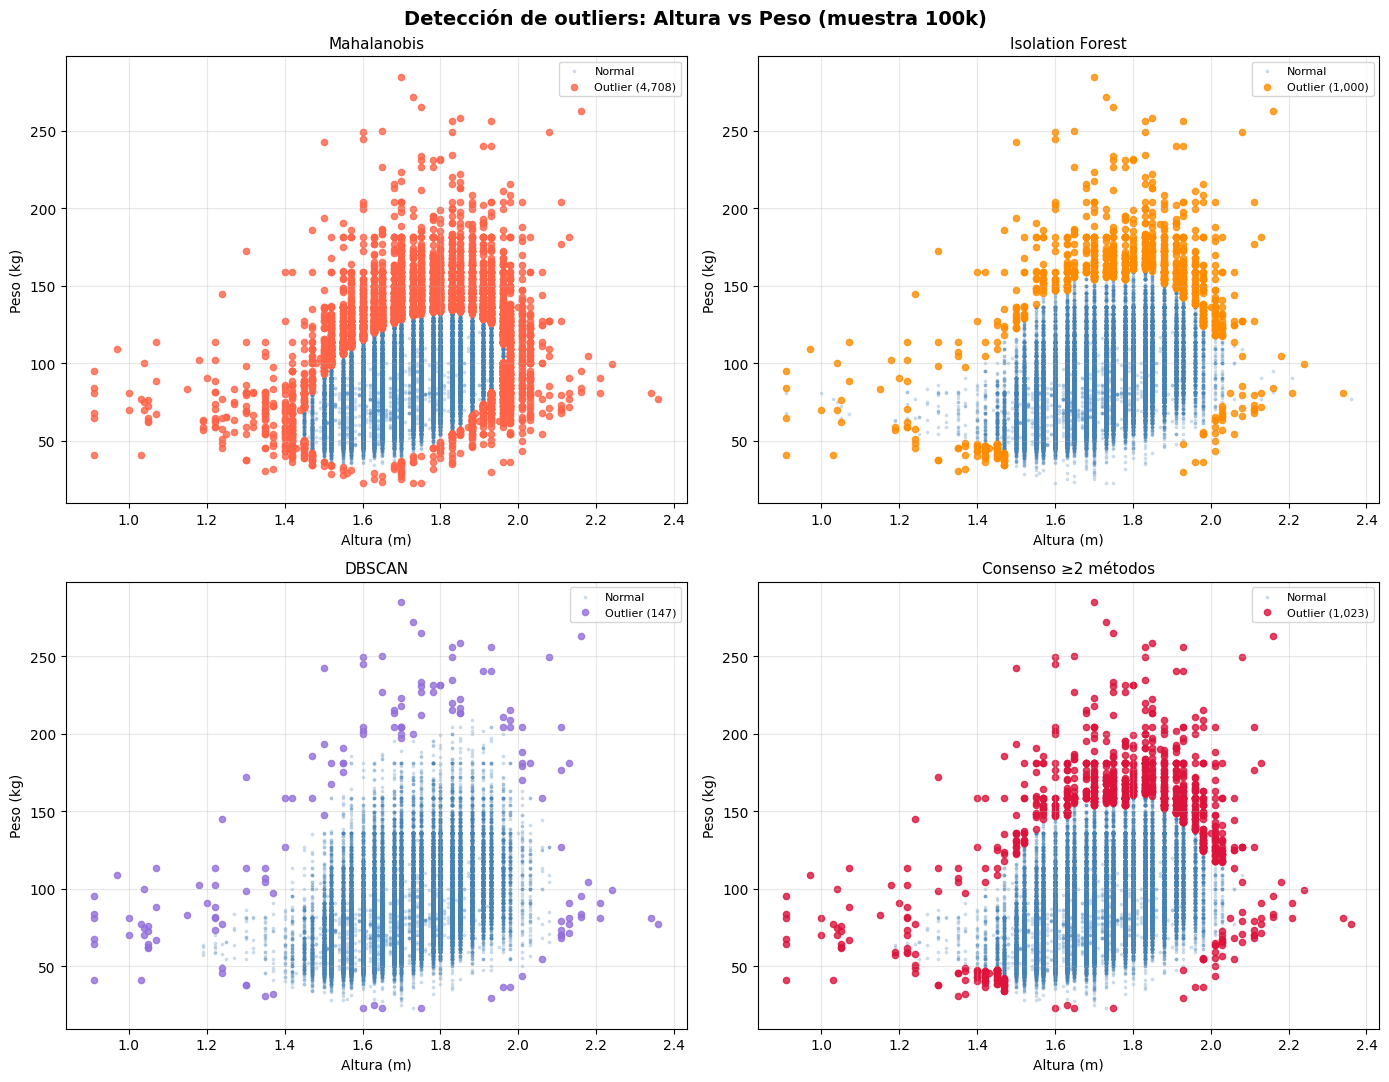

In [ ]:
# ════════════════════════════════════════════════════════════
# 1. MUESTRA PARA CÓMPUTO
# ════════════════════════════════════════════════════════════
np.random.seed(42)
idx_muestra = np.random.choice(len(df), size=100_000, replace=False)
df_sample = df.iloc[idx_muestra].reset_index(drop=True)
X = df_sample[["HeightInMeters", "WeightInKilograms"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ════════════════════════════════════════════════════════════
# 2. MAHALANOBIS
# ════════════════════════════════════════════════════════════
cov_inv = np.linalg.inv(np.cov(X.T))
mean = X.mean(axis=0)
dist_mahal = np.array([mahalanobis(x, mean, cov_inv) for x in X])
outlier_mahal = dist_mahal > np.sqrt(5.99)  # chi2(2, 0.975)
print(f"Mahalanobis     — outliers: {outlier_mahal.sum():,}")

# ════════════════════════════════════════════════════════════
# 3. ISOLATION FOREST
# ════════════════════════════════════════════════════════════
iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
outlier_iso = iso.fit_predict(X_scaled) == -1
print(f"Isolation Forest — outliers: {outlier_iso.sum():,}")

# ════════════════════════════════════════════════════════════
# 4. DBSCAN
# ════════════════════════════════════════════════════════════
dbscan = DBSCAN(eps=0.4, min_samples=10, n_jobs=-1)
outlier_dbscan = dbscan.fit_predict(X_scaled) == -1
print(f"DBSCAN           — outliers: {outlier_dbscan.sum():,}")

# ════════════════════════════════════════════════════════════
# 5. CONSENSO (≥2 métodos)
# ════════════════════════════════════════════════════════════
votos = outlier_mahal.astype(int) + outlier_iso.astype(int) + outlier_dbscan.astype(int)
outlier_consenso = votos >= 2
print(f"Consenso ≥2      — outliers: {outlier_consenso.sum():,}")

# ════════════════════════════════════════════════════════════
# 6. GRÁFICAS
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Detección de outliers: Altura vs Peso (muestra 100k)",
             fontsize=14, fontweight="bold")

metodos = [
    ("Mahalanobis",          outlier_mahal,    "tomato"),
    ("Isolation Forest",     outlier_iso,      "darkorange"),
    ("DBSCAN",               outlier_dbscan,   "mediumpurple"),
    ("Consenso ≥2 métodos",  outlier_consenso, "crimson"),
]

for ax, (titulo, flags, color) in zip(axes.flat, metodos):
    ax.scatter(X[~flags, 0], X[~flags, 1],
               s=3, alpha=0.2, color="steelblue", label="Normal")
    ax.scatter(X[flags, 0],  X[flags, 1],
               s=20, alpha=0.8, color=color, label=f"Outlier ({flags.sum():,})")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("Altura (m)")
    ax.set_ylabel("Peso (kg)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outliers_altura_peso.png", dpi=150, bbox_inches="tight")
plt.show()

DBSCAN ofrece el mejor ajuste visual, pero su costo computacional sobre el dataset completo es prohibitivo. Como alternativa, se replican sus criterios usando cotas médicamente fundamentadas sobre el BMI: cualquier valor fuera del rango fisiológicamente posible (BMI < 12 o BMI > 70) se considera un error de captura o un caso extremo irrelevante para el modelo.

Filas con BMI fuera de [12, 70]: 393
  BMI < 12: 143
  BMI > 70: 250


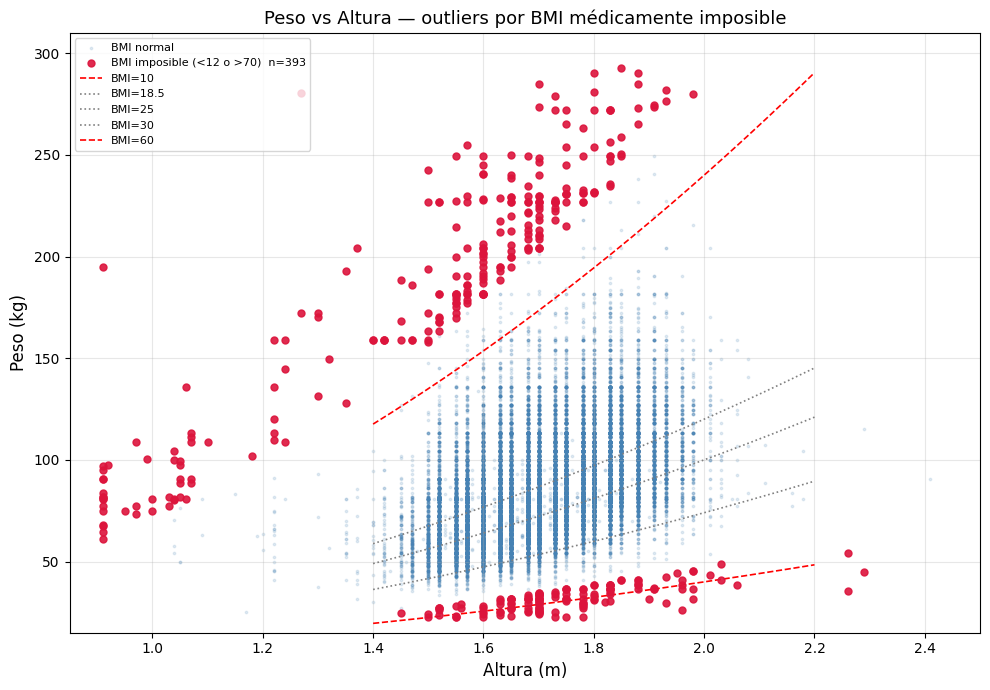

In [10]:
# ════════════════════════════════════════════════════════════
# GRÁFICA: Peso vs Altura coloreado por BMI imposible
# ════════════════════════════════════════════════════════════
BMI_MIN = 12
BMI_MAX = 70

mask_imposible = (df["BMI"] < BMI_MIN) | (df["BMI"] > BMI_MAX)
mask_normal    = ~mask_imposible

print(f"Filas con BMI fuera de [{BMI_MIN}, {BMI_MAX}]: {mask_imposible.sum():,}")
print(f"  BMI < {BMI_MIN}: {(df['BMI'] < BMI_MIN).sum():,}")
print(f"  BMI > {BMI_MAX}: {(df['BMI'] > BMI_MAX).sum():,}")

# Curvas de BMI constante para referencia
altura_range = np.linspace(1.40, 2.20, 300)
fig, ax = plt.subplots(figsize=(10, 7))

# Puntos normales (muestra para no saturar)
np.random.seed(42)
idx_norm = np.random.choice(np.where(mask_normal)[0], size=50_000, replace=False)
ax.scatter(df.iloc[idx_norm]["HeightInMeters"],
           df.iloc[idx_norm]["WeightInKilograms"],
           s=3, alpha=0.15, color="steelblue", label="BMI normal")

# Puntos imposibles (todos, son pocos)
ax.scatter(df.loc[mask_imposible, "HeightInMeters"],
           df.loc[mask_imposible, "WeightInKilograms"],
           s=25, alpha=0.9, color="crimson", zorder=5,
           label=f"BMI imposible (<{BMI_MIN} o >{BMI_MAX})  n={mask_imposible.sum():,}")

# Líneas de BMI de referencia
for bmi, color, ls in [(10, "red", "--"), (18.5, "gray", ":"),
                        (25, "gray", ":"), (30, "gray", ":"), (60, "red", "--")]:
    peso_curva = bmi * altura_range**2
    ax.plot(altura_range, peso_curva, color=color, linestyle=ls, linewidth=1.2,
            label=f"BMI={bmi}" if color == "red" else f"BMI={bmi}")

ax.set_xlabel("Altura (m)", fontsize=12)
ax.set_ylabel("Peso (kg)", fontsize=12)
ax.set_title("Peso vs Altura — outliers por BMI médicamente imposible", fontsize=13)
ax.set_xlim(0.85, 2.50)
ax.set_ylim(15, 310)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outliers_bmi_manual.png", dpi=150, bbox_inches="tight")
plt.show()

El criterio basado en BMI delimita bien la región de registros anómalos. Antes de eliminar, se verifica cuántos positivos se perderían con distintas combinaciones de cotas para altura, peso y BMI.

In [26]:
# ════════════════════════════════════════════════════════════
# DIAGNÓSTICO ANTES DE ELIMINAR
# ════════════════════════════════════════════════════════════
mask_bmi     = (df["BMI"] < 12) | (df["BMI"] > 60)
mask_altura  = (df["HeightInMeters"] <= 1.2) | (df["HeightInMeters"] > 2.1)
mask_peso    = df["WeightInKilograms"] > 220

mask_total   = mask_bmi | mask_altura | mask_peso

total_filas  = mask_total.sum()
positivos    = df["HadHeartAttack"].eq("Yes")

print(f"Filas afectadas por criterio:")
print(f"  BMI < 12 o > 70          : {mask_bmi.sum():,}  ({mask_bmi.sum()/len(df)*100:.2f}%)")
print(f"  Altura <= 1m o > 2.05m   : {mask_altura.sum():,}  ({mask_altura.sum()/len(df)*100:.2f}%)")
print(f"  Peso > 200 kg            : {mask_peso.sum():,}  ({mask_peso.sum()/len(df)*100:.2f}%)")
print(f"  TOTAL (unión)            : {mask_total.sum():,}  ({mask_total.sum()/len(df)*100:.2f}%)")

print(f"\nPositivos (HadHeartAttack=Yes) que se perderían:")
print(f"  BMI          : {(mask_bmi & positivos).sum():,}")
print(f"  Altura       : {(mask_altura & positivos).sum():,}")
print(f"  Peso         : {(mask_peso & positivos).sum():,}")
print(f"  TOTAL        : {(mask_total & positivos).sum():,}  "
      f"({(mask_total & positivos).sum() / positivos.sum() * 100:.2f}% de todos los positivos)")

Filas afectadas por criterio:
  BMI < 12 o > 70          : 884  (0.21%)
  Altura <= 1m o > 2.05m   : 235  (0.06%)
  Peso > 200 kg            : 134  (0.03%)
  TOTAL (unión)            : 1,045  (0.25%)

Positivos (HadHeartAttack=Yes) que se perderían:
  BMI          : 71
  Altura       : 12
  Peso         : 8
  TOTAL        : 76  (0.32% de todos los positivos)


El resultado es satisfactorio. Las cotas definidas —BMI fuera de [12, 70], altura fuera de (1.20 m, 2.10 m] y peso mayor de 220 kg— están justificadas fisiológicamente y, adicionalmente, se verificó que ni la altura ni el peso son variables de alta relevancia para predecir `HadHeartAttack`. Esto sugiere que los registros eliminados corresponden principalmente a errores de medición o datos incompletos, y su exclusión reduce la varianza del modelo sin penalización apreciable en rendimiento.

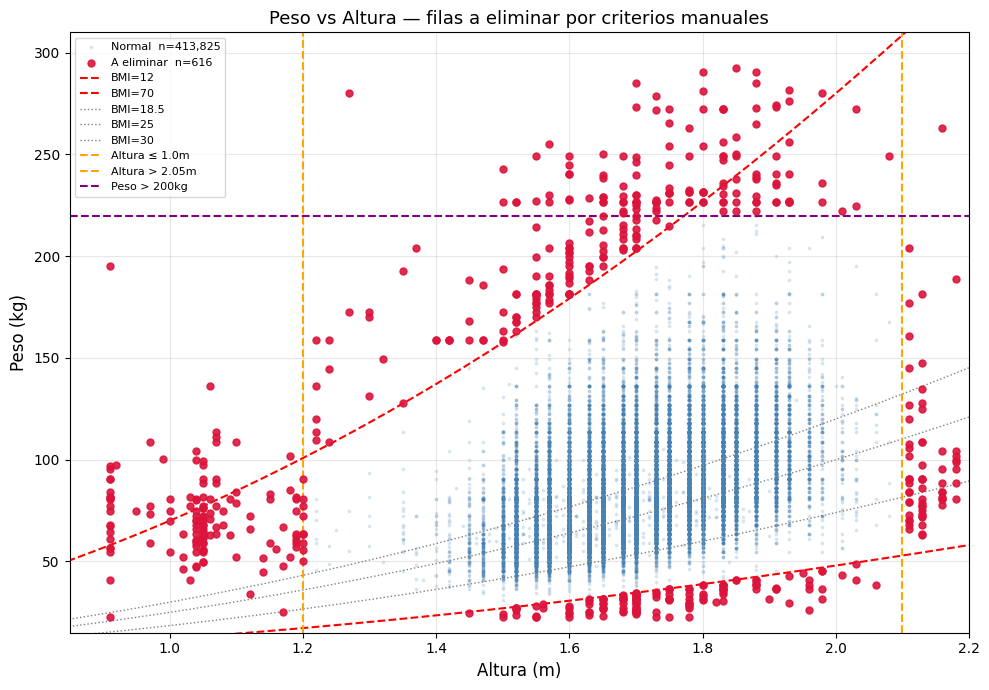

In [25]:
# ════════════════════════════════════════════════════════════
# MÁSCARAS
# ════════════════════════════════════════════════════════════
mask_bmi    = (df["BMI"] < 12) | (df["BMI"] > 70)
mask_altura = (df["HeightInMeters"] <= 1.2) | (df["HeightInMeters"] > 2.1)
mask_peso   = df["WeightInKilograms"] > 220
mask_total  = mask_bmi | mask_altura | mask_peso
mask_normal = ~mask_total

# ════════════════════════════════════════════════════════════
# GRÁFICA
# ════════════════════════════════════════════════════════════
altura_range = np.linspace(0.80, 2.20, 300)

fig, ax = plt.subplots(figsize=(10, 7))

# Normales (muestra)
np.random.seed(42)
idx_norm = np.random.choice(np.where(mask_normal)[0], size=50_000, replace=False)
ax.scatter(df.iloc[idx_norm]["HeightInMeters"],
           df.iloc[idx_norm]["WeightInKilograms"],
           s=3, alpha=0.15, color="steelblue", label=f"Normal  n={mask_normal.sum():,}")

# Outliers (todos)
ax.scatter(df.loc[mask_total, "HeightInMeters"],
           df.loc[mask_total, "WeightInKilograms"],
           s=25, alpha=0.9, color="crimson", zorder=5,
           label=f"A eliminar  n={mask_total.sum():,}")

# Curvas BMI de referencia
for bmi, color, ls, lw in [(12, "red", "--", 1.5), (70, "red", "--", 1.5),
                            (18.5, "gray", ":", 1.0), (25, "gray", ":", 1.0),
                            (30, "gray", ":", 1.0)]:
    peso_curva = bmi * altura_range**2
    ax.plot(altura_range, peso_curva, color=color, linestyle=ls,
            linewidth=lw, label=f"BMI={bmi}")

# Límites de altura
ax.axvline(x=1.2,  color="orange", linestyle="--", linewidth=1.5, label="Altura ≤ 1.0m")
ax.axvline(x=2.1, color="orange", linestyle="--", linewidth=1.5, label="Altura > 2.05m")

# Límite de peso
ax.axhline(y=220, color="purple", linestyle="--", linewidth=1.5, label="Peso > 200kg")

ax.set_xlabel("Altura (m)", fontsize=12)
ax.set_ylabel("Peso (kg)", fontsize=12)
ax.set_title("Peso vs Altura — filas a eliminar por criterios manuales", fontsize=13)
ax.set_xlim(0.85, 2.20)
ax.set_ylim(15, 310)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outliers_manuales.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# ════════════════════════════════════════════════════════════
# 1. OUTLIERS ANTROPOMÉTRICOS
# ════════════════════════════════════════════════════════════
mask_bmi    = (df["BMI"] < 12) | (df["BMI"] > 70)
mask_altura = (df["HeightInMeters"] <= 1.2) | (df["HeightInMeters"] > 2.1)
mask_peso   = df["WeightInKilograms"] > 220
mask_antrop = mask_bmi | mask_altura | mask_peso

positivos_antrop = (mask_antrop & df["HadHeartAttack"].eq("Yes")).sum()
print(f"Outliers antropométricos     : {mask_antrop.sum():,} filas")
print(f"  Positivos perdidos         : {positivos_antrop:,} "
      f"({positivos_antrop / df['HadHeartAttack'].eq('Yes').sum() * 100:.2f}% de todos los positivos)")

df = df[~mask_antrop].copy()
print(f"Shape tras eliminar outliers antropométricos: {df.shape}")

# ════════════════════════════════════════════════════════════
# 2. OUTLIERS SUEÑO (> 16 horas)
# ════════════════════════════════════════════════════════════
mask_sueno = df["SleepHours"] > 16

positivos_sueno = (mask_sueno & df["HadHeartAttack"].eq("Yes")).sum()
print(f"\nOutliers SleepHours > 16h    : {mask_sueno.sum():,} filas")
print(f"  Positivos perdidos         : {positivos_sueno:,} "
      f"({positivos_sueno / df['HadHeartAttack'].eq('Yes').sum() * 100:.2f}% de todos los positivos)")

df = df[~mask_sueno].copy()
print(f"Shape tras eliminar outliers de sueño: {df.shape}")

# ════════════════════════════════════════════════════════════
# 3. VERIFICACIÓN FINAL Y GUARDADO
# ════════════════════════════════════════════════════════════
print(f"\n=== RESUMEN FINAL ===")
print(f"Shape final                  : {df.shape}")
print(f"Nulos restantes              : {df.isnull().sum().sum()}")
print(f"Distribución target:")
print(f"  No  : {df['HadHeartAttack'].eq('No').sum():,}")
print(f"  Yes : {df['HadHeartAttack'].eq('Yes').sum():,}")
print(f"  % positivos: {df['HadHeartAttack'].eq('Yes').mean()*100:.2f}%")

df.to_csv("heart_clean.csv", index=False)
print(f"\n✓ Dataset guardado como heart_clean.csv")

Outliers antropométricos     : 616 filas
  Positivos perdidos         : 47 (0.20% de todos los positivos)
Shape tras eliminar outliers antropométricos: (413825, 40)

Outliers SleepHours > 16h    : 365 filas
  Positivos perdidos         : 54 (0.23% de todos los positivos)
Shape tras eliminar outliers de sueño: (413460, 40)

=== RESUMEN FINAL ===
Shape final                  : (413460, 40)
Nulos restantes              : 0
Distribución target:
  No  : 389,886
  Yes : 23,574
  % positivos: 5.70%

✓ Dataset guardado como heart_clean.csv
